# Gradient Boosting

**Gradient Boosting** is trained on the identical prepared data used by every model; only the algorithm differs.

| | |
|---|---|
| **Hyperparameters** | Bayesian search (Optuna TPE around the grid best, 5-fold CV on seed-42 train) — defined once in `src/models.py` (`FINAL_PARAMS`) |
| **Target** | log(1 + Rent); predictions are converted back to rupees |
| **Inputs** | the 29 prepared features |
| **Feature scaling** | none (not needed) |
| **Evaluation** | 3 seeds (42, 43, 44): each seed draws a new 70/15/15 split and new CV folds |
| **Outputs** | its row in `reports/results.csv` · `models/gradient_boosting.joblib` · `visualizations/gradient_boosting.png` |

## 1. Setup

In [1]:
import sys, pathlib, warnings
ROOT = next((p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents) if (p / 'src' / 'config.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the project folder (the one that contains src/).')
sys.path.insert(0, str(ROOT))   # project root -> `import src`, whatever the working folder
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)
from src import config
from src.data_loading import load_raw
from src.data_cleaning import (rule_strip_text, rule_validity, rule_rent_per_sqft,
                               rule_dedup_relisted, rule_parse_floor)
from src.models import display_name, final_params, PARAM_SOURCE
from src.evaluation import run_model
from src.prediction import save_model
from src.plotting import plot_diagnostics

MODEL_KEY = 'gradient_boosting'

## 2. Load and clean the data
The same rules run in every notebook, in the same order. They are fixed conditions, not hand-picked rows, and the
cleaned data stays in memory — nothing is written to disk.

In [2]:
raw = load_raw()   # data/raw/House_Rent_Dataset.csv — not in the repository, see data/README.md
print(f"Raw dataset:     {raw.shape[0]:,} rows × {raw.shape[1]} columns")

cleaning_steps = [
    ("trim text, normalise locality names",              rule_strip_text),
    ("keep valid rows (Rent, Size > 0; BHK, Bath ≥ 1)",  rule_validity),
    ("drop implausible rent (> Rs 500 per sq ft)",       rule_rent_per_sqft),
    ("drop re-listed duplicates",                        rule_dedup_relisted),
    ("parse Floor → current_floor, total_floors",        rule_parse_floor),
]
clean = raw
for label, rule in cleaning_steps:
    before = len(clean)
    clean = rule(clean)
    print(f"  {label:<50} {before:>5,} → {len(clean):>5,} rows")
clean = clean.reset_index(drop=True)
print(f"Cleaned dataset: {clean.shape[0]:,} rows × {clean.shape[1]} columns")
print("Columns:", ", ".join(clean.columns))

Raw dataset:     4,746 rows × 12 columns
  trim text, normalise locality names                4,746 → 4,746 rows
  keep valid rows (Rent, Size > 0; BHK, Bath ≥ 1)    4,746 → 4,746 rows
  drop implausible rent (> Rs 500 per sq ft)         4,746 → 4,740 rows
  drop re-listed duplicates                          4,740 → 4,731 rows
  parse Floor → current_floor, total_floors          4,731 → 4,731 rows
Cleaned dataset: 4,731 rows × 14 columns
Columns: Posted On, BHK, Rent, Size, Floor, Area Type, Area Locality, City, Furnishing Status, Tenant Preferred, Bathroom, Point of Contact, current_floor, total_floors


## 3. Model and hyperparameters

In [3]:
print(f"{display_name(MODEL_KEY)} — {PARAM_SOURCE[MODEL_KEY]}")
params = final_params(MODEL_KEY)
print("\n".join(f"  {k} = {v}" for k, v in params.items()) if params else "  (library defaults)")

Gradient Boosting — Bayesian search (Optuna TPE around the grid best, 5-fold CV on seed-42 train)
  n_estimators = 282
  learning_rate = 0.05920605525727517
  max_depth = 3
  subsample = 0.540062581916704
  min_samples_leaf = 20
  max_features = 0.4521695605697275
  loss = huber


## 4. Train and evaluate on three seeds
For each seed: split 70/15/15 (stratified on rent), fit on the training split, run 5-fold cross-validation on the
training split (all preprocessing re-fitted inside every fold), then score the validation and test splits once.
Errors are in rupees per month.

In [4]:
row, per_seed, first, averaged = run_model(MODEL_KEY, clean=clean, verbose=False)
per_seed.rename(columns={'seed': 'Seed', 'train_rmse': 'Train RMSE', 'cv_rmse': 'CV RMSE', 'val_rmse': 'Val RMSE',
                         'test_rmse': 'Test RMSE', 'test_r2': 'Test R²', 'test_mae': 'Test MAE',
                         'test_mdape': 'Test Median % Error'}).set_index('Seed')

,Train RMSE,CV RMSE,Val RMSE,Test RMSE,Test R²,Test MAE,Test Median % Error
Seed,,,,,,,
42,"25,129.09","26,277.09","42,065.42","21,506.23",0.84,"9,528.40",22.09
43,"28,193.09","30,569.43","23,778.74","22,163.60",0.81,"8,790.72",20.23
44,"29,236.44","29,579.01","29,578.06","22,560.29",0.84,"9,154.03",20.53


## 5. Result — mean ± std over the three seeds (saved to `reports/results.csv`)

In [5]:
pd.DataFrame([row]).set_index('Model')

,Train RMSE,CV RMSE,Val RMSE,Test RMSE,Test R²,Test MAE,Test Median % Error
Model,,,,,,,
Gradient Boosting,27519.54 ± 2134.91,28808.51 ± 2247.51,31807.41 ± 9344.96,22076.71 ± 532.37,0.83 ± 0.02,9157.72 ± 368.86,20.95 ± 1.00


## 6. Save the averaged model
`models/gradient_boosting.joblib` keeps the three fitted pipelines (one per seed, each with its own preprocessing); a new
listing's prediction is their average. Use it for **new** listings only — every dataset row is in some seed's
training data, so scoring it on these splits would be leaked. The honest scores are the per-seed ones above.

In [6]:
print(f'Saved {save_model(averaged).relative_to(config.ROOT)} — {averaged}')

Saved models/gradient_boosting.joblib — SeedAveragedModel(Gradient Boosting, seeds=[42, 43, 44])


## 7. Diagnostics — seed 42, test split

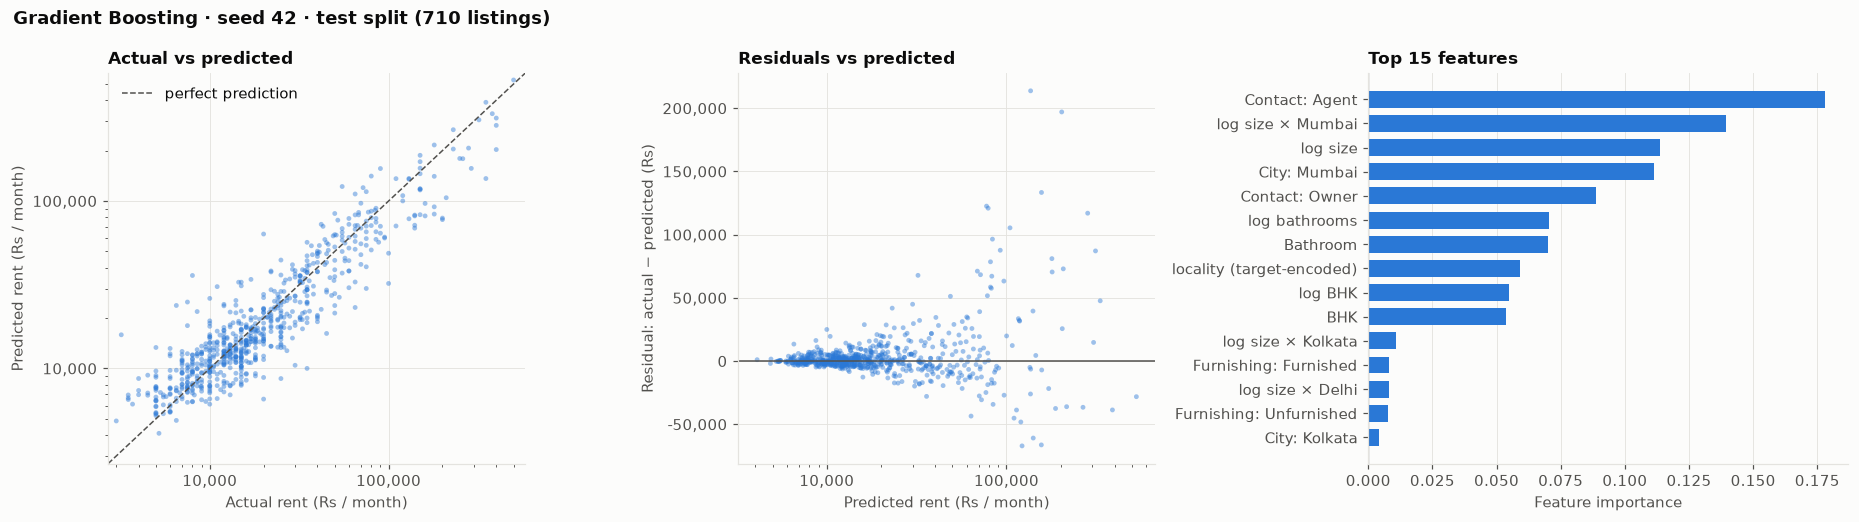

In [7]:
fig = plot_diagnostics(first['model'], first['pred'], first['data'], display_name(MODEL_KEY),
                       save_path=config.VIZ_DIR / f'{MODEL_KEY}.png')